# Task VIII - Quantum Vision Transformer

This task implements a classical Vision Transformer (ViT) for MNIST classification, evaluates its performance, and discusses how to extend the architecture to a Quantum Vision Transformer (QViT).

## Steps
1. Implement a classical Vision Transformer for MNIST.
2. Train and evaluate on MNIST test data.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

In [3]:
import os
os.makedirs('task8', exist_ok=True)
print("Directory 'task8' created successfully (if it didn't exist already).")

Directory 'task8' created successfully (if it didn't exist already).


Epoch 1 completed.
Epoch 2 completed.
Epoch 3 completed.
Epoch 4 completed.
Epoch 5 completed.
Epoch 6 completed.
Epoch 7 completed.
Epoch 8 completed.
Epoch 9 completed.
Epoch 10 completed.
Epoch 11 completed.
Epoch 12 completed.
Epoch 13 completed.
Epoch 14 completed.
Epoch 15 completed.
Epoch 16 completed.
ViT Test Accuracy: 0.9810


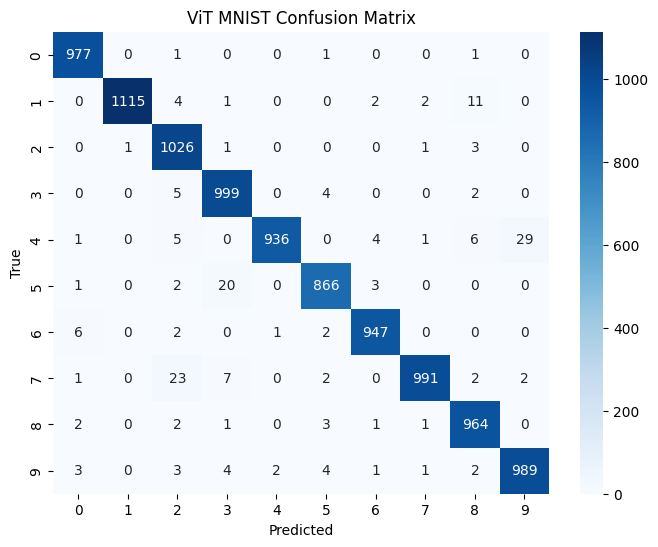

In [4]:
# Vision Transformer (ViT) implementation for MNIST
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=28, patch_size=7, in_chans=1, embed_dim=64):
        super().__init__()
        self.n_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)
    def forward(self, x):
        x = self.proj(x)  # [B, embed_dim, n_patches_sqrt, n_patches_sqrt]
        x = x.flatten(2).transpose(1, 2)  # [B, n_patches, embed_dim]
        return x

class ViT(nn.Module):
    def __init__(self, img_size=28, patch_size=7, in_chans=1, embed_dim=64, num_heads=4, num_layers=2, num_classes=10):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_chans, embed_dim)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, self.patch_embed.n_patches + 1, embed_dim))
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.head = nn.Linear(embed_dim, num_classes)
    def forward(self, x):
        x = self.patch_embed(x)
        B = x.shape[0]
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embed
        x = self.transformer(x)
        x = x[:, 0]  # CLS token
        x = self.head(x)
        return x

# Training and evaluation

def train_vit():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
    testloader = torch.utils.data.DataLoader(testset, batch_size=256, shuffle=False)

    model = ViT().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Training
    for epoch in range(16):
        model.train()
        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        print(f"Epoch {epoch+1} completed.")

    # Evaluation
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    acc = correct / total
    print(f"ViT Test Accuracy: {acc:.4f}")

    # Plot confusion matrix
    from sklearn.metrics import confusion_matrix
    import seaborn as sns

    os.makedirs('task8', exist_ok=True)

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('ViT MNIST Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.savefig('task8/vit_mnist_confusion.png')
    plt.show()
    # Save accuracy
    with open('task8/vit_mnist_results.txt', 'w') as f:
        f.write(f'ViT Test Accuracy: {acc:.4f}\n')

if __name__ == "__main__":
    train_vit()
